# Double Machine Learning (DoubleML): Water Treatment & Child Diarrhea

This notebook demonstrates a **best-practice, pedagogical workflow** for estimating causal effects using the **Double Machine Learning (DML)** framework, specifically the **Interactive Regression Model (IRM)** from the [`DoubleML`](https://docs.doubleml.org) package.

## Research Question
**Does household water treatment reduce the probability of diarrhea in children under five?**

## Why DoubleML?
Traditional regression adjustment requires correctly specifying the functional form of confounders. DML uses machine learning to flexibly model nuisance functions (the propensity score and the outcome model) while maintaining **<b>√n-consistent</b>** and **<b>asymptotically normal</b>** estimates of the causal parameter via **Neyman-orthogonal scores** and **cross-fitting**.

## Assumptions
1. **Unconfoundedness (Conditional Independence):** Treatment assignment is as-good-as-random conditional on observed covariates.
2. **Overlap (Positivity):** All observations have a non-zero probability of receiving or not receiving treatment.
3. **Consistency:** The observed outcome corresponds to the potential outcome under the realized treatment.

## 1. Setup & Imports

In [1]:
import warnings
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadstat
from matplotlib.lines import Line2D
from scipy.stats import norm as scipy_norm

# --- Engine -------------------------------------------------------------------
# nb_dml reuses the production package in ../final as the single source of
# methodological truth: 7 ML learners (OLS, Lasso, Ridge, ENet, RF, XGB,
# Stacked) with bounded (ProbaRegressor) outcome nuisances, PSU-clustered IRM
# with a 3-attempt fallback, structured sensitivity, and LaTeX table writers.
sys.path.insert(0, str(Path('..') / 'final'))
sys.path.insert(0, '.')
import nb_dml as N
from config import CLUSTER_VAR

sns.set_theme(style='whitegrid', context='notebook')
warnings.filterwarnings('ignore')
np.set_printoptions(precision=4, suppress=True)

LEARNERS = N.get_learners()       # 7 learners, reused across every spec
LEARNER_LABELS = N.LEARNER_LABELS

# Accumulators -> consolidated LaTeX export at the end (Section 15)
ALL_IRM_RESULTS  = []   # IRM dicts, any treatment, base spec (U5 + HH)
HH_BASE_RESULTS  = []   # HH any-treatment base dicts
U5_robust_results = []  # filled in Section 7
HH_ROBUST_RESULTS = []  # filled in Section 14
ALL_APOS_ROWS    = []   # APOS contrast rows (specific treatments), all outcomes
GATE_EXPORT      = {}   # {outcome: {grouping: {summary, labels}}}


## 2. Data Engineering

We load the Stata dataset and construct binary indicators for the treatment (`water_treatment`) and outcome (`diarrhea`), alongside a rich set of confounders.

**Treatment:** Household uses any water treatment (`WQ15_g > 0`).
**Outcome:** Child had diarrhea in the last two weeks (`diarrhea == 1`).
**Confounders:** Wealth, education, sanitation, demographics, geography, and water source.

In [2]:
def load_and_prepare_data(file_path):
    """
    Load Stata .dta file and engineer binary/categorical features for DML.
    Returns the full dataframe, base confounders, and hygiene columns.
    """
    dt, meta = pyreadstat.read_dta(file_path)
    dt = dt.copy()

    # Core causal variables
    dt['diarrhea'] = (dt['diarrhea'] == 1).astype(int)
    dt['water_treatment'] = (dt['WQ15_g'] > 0).astype(int)

    # Specific treatment dummies (WQ15_g coding: 1=boil, 2=chlorine, 3=filter, 98=other)
    TREATMENT_MAP = {1: 'treat_boil', 2: 'treat_chlorine', 3: 'treat_filter', 98: 'treat_other'}
    for code, name in TREATMENT_MAP.items():
        dt[name] = (dt['WQ15_g'] == code).astype(int)

    # --- Direct control mappings ---
    CONTROL_MAP = {
        'urban_bin': ('urban', lambda x: x.astype(int)),
        'num_children': ('HHCHILDREN', lambda x: x.fillna(0).astype(int)),
        'child_age': ('age', lambda x: x.fillna(0).astype(int)),
        'child_sex_male': ('male', lambda x: x.fillna(0).astype(int)),
    }

    # --- Categorical encodings (binary dummies, reference category dropped) ---
    CATEGORICAL_MAP = {
        'windex5': {'prefix': 'wealth_q', 'levels': [2, 3, 4, 5]},
        'helevel': {'prefix': 'edu_', 'levels': {1: 'primary', 2: 'secondary', 98: 'missing'}},
        'Toilet': {'prefix': 'toilet_', 'levels': {2: 'pit_latrine', 3: 'open_defecation', 98: 'toilet_missing'}}
    }

    final_cols = []

    for col, (raw, func) in CONTROL_MAP.items():
        dt[col] = func(dt[raw])
        final_cols.append(col)

    for raw_col, spec in CATEGORICAL_MAP.items():
        if raw_col not in dt.columns:
            continue
        levels = spec['levels']
        prefix = spec['prefix']
        if isinstance(levels, list):
            for l in levels:
                col_name = f"{prefix}{l}"
                dt[col_name] = (dt[raw_col] == l).astype(int)
                final_cols.append(col_name)
        else:
            for val, label in levels.items():
                col_name = f"{prefix}{label}"
                dt[col_name] = (dt[raw_col] == val).astype(int)
                final_cols.append(col_name)

    # Water source dummies
    if 'WS1_g' in dt.columns:
        ws_dummies = pd.get_dummies(dt['WS1_g'], prefix='ws1g')
        ws_dummies = ws_dummies.drop(ws_dummies.columns[0], axis=1)
        final_cols.extend(ws_dummies.columns.tolist())
        dt = pd.concat([dt, ws_dummies], axis=1)

    # Country fixed effects
    if 'Country' in dt.columns:
        country_dummies = pd.get_dummies(dt['Country'], prefix='country', drop_first=True)
        final_cols.extend(country_dummies.columns.tolist())
        dt = pd.concat([dt, country_dummies], axis=1)

    # Risk source indicators
    if 'RiskSource' in dt.columns:
        for rs in [0, 1]:
            col_name = f'risk_source_{rs}'
            dt[col_name] = (dt['RiskSource'] == rs).astype(int)
            final_cols.append(col_name)

    # Hygiene variables (robustness specification)
    dt['soap_water'] = dt['SoapandWater'].fillna(0).astype(int)
    dt['stored_covered'] = dt['water_stored_covered'].fillna(0).astype(int)
    hygiene_cols = ['soap_water', 'stored_covered']

    base_confounders = [c for c in final_cols if c in dt.columns]
    return dt, base_confounders, hygiene_cols


# -----------------------------------------------------------------------------
DATA_PATH = Path('..') / 'Data' / '3. Final' / 'MASTER_MICS_FINAL_U5.dta'
dt, base_confounders, hygiene_cols = load_and_prepare_data(DATA_PATH)

print(f"Dataset shape: {dt.shape}")
print(f"Base confounders ({len(base_confounders)}): {base_confounders[:5]} ...")
print(f"\nTreatment rates:")
print(f"  Any treatment:     {dt['water_treatment'].mean():.3f}  (N={int(dt['water_treatment'].sum())})")
for t in ['treat_boil', 'treat_chlorine', 'treat_filter', 'treat_other']:
    print(f"  {t}: {dt[t].mean():.3f}  (N={int(dt[t].sum())})")
print(f"\nOutcome rate (diarrhea): {dt['diarrhea'].mean():.3f}")

Dataset shape: (36121, 842)
Base confounders (46): ['urban_bin', 'num_children', 'child_age', 'child_sex_male', 'wealth_q2'] ...

Treatment rates:
  Any treatment:     0.194  (N=7024)
  treat_boil: 0.076  (N=2746)
  treat_chlorine: 0.020  (N=737)
  treat_filter: 0.072  (N=2593)
  treat_other: 0.026  (N=948)

Outcome rate (diarrhea): 0.139


## 3. Why IRM?

Because our treatment is **binary** and we do not want to impose a linear functional form on the propensity score, we use the **Interactive Regression Model (IRM)**.

The IRM estimates the Average Treatment Effect (ATE) by modeling two nuisance functions:
- **Propensity Score** $m(X) = P(D=1|X)$: probability of treatment given covariates. We model this with classifiers.
- **Outcome Regression** $g(X) = E[Y|X]$: expected outcome given covariates. We model this with regressors.

DoubleML then constructs a Neyman-orthogonal score that is robust to slower-than-parametric convergence rates of these nuisance estimators.

## 4. Base Specification: A Single Learner Walkthrough

Before the full sweep we fit **one** learner (Lasso / L1-Logit) to show the core API. Two choices match the production pipeline (`../final`) and depart from a textbook example:

- **Bounded outcome nuisance.** The outcome is binary, so `ml_g` estimates a probability. We wrap a classifier (`ProbaRegressor`) so its `predict()` returns `predict_proba[:, 1]` $\in [0, 1]$ — a plain regressor would give an unbounded LPM fit and can destabilise the inverse-propensity weights.
- **PSU-clustered SEs.** MICS uses cluster sampling, so we pass `cluster_cols='Cluster_var'` with a 3-attempt fallback (default folds + clusters -> 2 folds + clusters -> 2 folds, no clusters) for degenerate cluster-fold splits.

`ml_g` $= E[Y\mid X]$ (bounded probability); `ml_m` $= P(D{=}1\mid X)$ (classifier).

In [3]:
# Base analysis frame (carries the PSU cluster id for clustered SEs)
df_base = N.analysis_frame(dt, 'diarrhea', 'water_treatment', base_confounders)
print(f"N = {len(df_base):,}  |  clustered: {CLUSTER_VAR in df_base.columns}"
      f"  |  clusters: {df_base[CLUSTER_VAR].nunique():,}")

# Walkthrough: a single learner (Lasso) -- PSU-clustered, bounded ml_g in [0,1]
res_lasso = N.fit_irm(df_base, 'diarrhea', 'water_treatment',
                      base_confounders, LEARNERS['lasso'])
print(f"\nLasso / L1-Logit IRM (ATE):")
print(f"  ATE      = {res_lasso['coef']:+.4f}")
print(f"  Std err  = {res_lasso['se']:.4f}")
print(f"  95% CI   = [{res_lasso['ci_lower']:.4f}, {res_lasso['ci_upper']:.4f}]")
print(f"  N        = {res_lasso['n']:,}  (treated {res_lasso['n_treated']:,})")
print(f"  RV       = {res_lasso['rv_q']*100:.2f}%   (sensitivity, rho=1)")


N = 36,121  |  clustered: True  |  clusters: 13,596



Lasso / L1-Logit IRM (ATE):
  ATE      = -0.0012
  Std err  = 0.0093
  95% CI   = [-0.0195, 0.0171]
  N        = 36,121  (treated 7,024)
  RV       = 0.08%   (sensitivity, rho=1)


### Interpreting the output
- **coef**: The estimated ATE. A negative coefficient implies water treatment *reduces* diarrhea probability.
- **std err**: Standard error from the asymptotic distribution.
- **t**: Wald statistic.
- **P>|t|**: Two-sided p-value.
- **[0.025, 0.975]**: 95% confidence interval.

## 5. Robustness Across Learners

We estimate the same ATE with **seven** learners — identical to the production package. Stability across linear, sparse, and tree learners means the result is not an artefact of functional form.

| Learner | `ml_g` (outcome, bounded) | `ml_m` (propensity) |
|---|---|---|
| **OLS** | Logit, no penalty | Logit |
| **Lasso** | L1-Logit | L1-Logit |
| **Ridge** | L2-Logit | L2-Logit |
| **Elastic Net** | EN-Logit | EN-Logit |
| **Random Forest** | RF classifier | RF classifier |
| **XGBoost** | XGB classifier | XGB classifier |
| **Stacked** | ensemble (Lasso+Ridge+RF, RidgeCV meta) | ensemble (Logit meta) |

All penalties are cross-validated; every `ml_g` is wrapped in `ProbaRegressor` so outcome predictions stay in $[0, 1]$. (The earlier stand-alone neural-net column is dropped to match the package's 7-learner set.)

In [4]:
# Full sweep: all 7 learners, clustered IRM, bounded outcome nuisance
print("U5 -- diarrhea -- any treatment -- 7 clustered IRM learners")
U5_base_results = N.fit_irm_all_learners(
    df_base, 'diarrhea', 'water_treatment', base_confounders, dataset_type='U5')
ALL_IRM_RESULTS += U5_base_results

results_base = N.results_to_frame(U5_base_results)
irm_stacked  = N.get_model(U5_base_results, 'stacked')   # for CATE/GATE/sensitivity
results_base[['Learner', 'ATE', 'Std Error', 'p-value', 'CI Lower', 'CI Upper', 'RV']].round(4)


U5 -- diarrhea -- any treatment -- 7 clustered IRM learners
  OLS            

ATE=-0.0059 (0.0067)  
  Lasso          

ATE=-0.0015 (0.0094)  
  Ridge          

ATE=-0.0069 (0.0066)  
  Elastic Net    

ATE=-0.0008 (0.0098)  
  Random Forest  

ATE=-0.0067 (0.0055)  
  XGBoost        

ATE=+0.0051 (0.0091)  
  Stacked        

ATE=-0.0064 (0.0056)  


,Learner,ATE,Std Error,p-value,CI Lower,CI Upper,RV
0,OLS,-0.0059,0.0067,0.3772,-0.0192,0.0073,0.0041
1,Lasso,-0.0015,0.0094,0.8728,-0.0205,0.0170,0.0011
2,Ridge,-0.0069,0.0066,0.2986,-0.0199,0.0061,0.0048
3,Elastic Net,-0.0008,0.0098,0.9385,-0.0200,0.0185,0.0005
4,Random Forest,-0.0067,0.0055,0.2222,-0.0175,0.0041,0.0046
5,XGBoost,0.0051,0.0091,0.5755,-0.0138,0.0228,0.0031
6,Stacked,-0.0064,0.0056,0.2534,-0.0173,0.0046,0.0048


### Visual Comparison
A **coefplot** lets us see at a glance whether the estimated ATEs and confidence intervals overlap across learners.

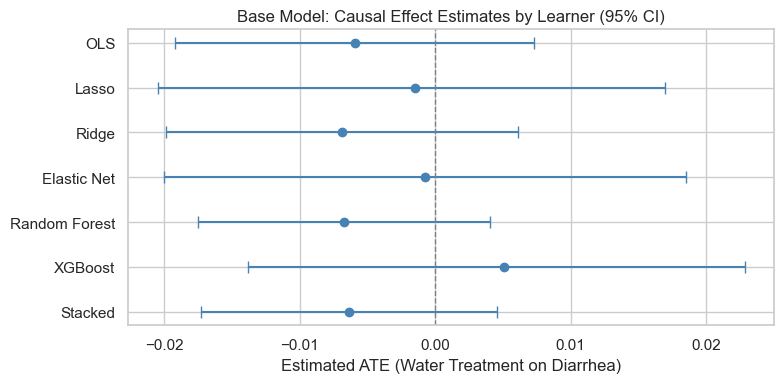

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))

y_pos = np.arange(len(results_base))
ate = results_base['ATE']
err_lower = ate - results_base['CI Lower']
err_upper = results_base['CI Upper'] - ate

ax.errorbar(ate, y_pos, xerr=[err_lower, err_upper], fmt='o', color='steelblue', ecolor='steelblue', capsize=4, markersize=6)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(results_base['Learner'])
ax.set_xlabel('Estimated ATE (Water Treatment on Diarrhea)')
ax.set_title('Base Model: Causal Effect Estimates by Learner (95% CI)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Stacked Ensemble Learner

Instead of picking one "best" learner, we can use a **stacking ensemble** that combines the predictions of multiple base learners. In the nuisance function estimation, the stacked ensemble should perform at least as well as the best individual learner, often improving stability.

We stack:
- Random Forest
- XGBoost
- Neural Net
- Ridge

The meta-learner is a Lasso (for regression) and a Logistic Regression (for classification), which learns the optimal weights.

In [6]:
# The stacked ensemble is learner #7 in the sweep above. Pull its fitted model
# for the heterogeneity (CATE/GATE) and sensitivity analyses that follow.
s = next(r for r in U5_base_results if r['learner'] == 'stacked')
print("Stacked ensemble (Lasso + Ridge + RF base, RidgeCV / Logit meta-learner)")
print(f"  ATE = {s['coef']:+.4f}   SE = {s['se']:.4f}   "
      f"95% CI [{s['ci_lower']:.4f}, {s['ci_upper']:.4f}]")
print(f"  RV = {s['rv_q']*100:.2f}%   RVa = {s['rv_qa']*100:.2f}%")


Stacked ensemble (Lasso + Ridge + RF base, RidgeCV / Logit meta-learner)
  ATE = -0.0064   SE = 0.0056   95% CI [-0.0173, 0.0046]
  RV = 0.48%   RVa = 0.00%


## 7. Robust Specification: Adding Hygiene Controls

To test sensitivity to omitted variable bias, we add hygiene variables (`soap_water`, `stored_covered`) as additional confounders. If the ATE is stable, it suggests our base results are robust.

In [7]:
# Robustness: add hygiene controls (soap+water, covered storage)
robust_confounders = base_confounders + hygiene_cols
df_robust = N.analysis_frame(dt, 'diarrhea', 'water_treatment', robust_confounders)

U5_robust_results = N.fit_irm_all_learners(
    df_robust, 'diarrhea', 'water_treatment', robust_confounders, dataset_type='U5')
results_robust = N.results_to_frame(U5_robust_results)
results_robust[['Learner', 'ATE', 'p-value', 'CI Lower', 'CI Upper']].round(4)


  OLS            

ATE=-0.0092 (0.0064)  
  Lasso          

ATE=-0.0055 (0.0089)  
  Ridge          

ATE=-0.0096 (0.0062)  
  Elastic Net    

ATE=-0.0012 (0.0098)  
  Random Forest  

ATE=-0.0054 (0.0056)  
  XGBoost        

ATE=-0.0023 (0.0086)  
  Stacked        

ATE=-0.0053 (0.0057)  


,Learner,ATE,p-value,CI Lower,CI Upper
0,OLS,-0.0092,0.1546,-0.0218,0.0035
1,Lasso,-0.0055,0.5378,-0.0221,0.0120
2,Ridge,-0.0096,0.1229,-0.0218,0.0026
3,Elastic Net,-0.0012,0.9059,-0.0203,0.0180
4,Random Forest,-0.0054,0.3383,-0.0164,0.0056
5,XGBoost,-0.0023,0.7935,-0.0191,0.0146
6,Stacked,-0.0053,0.3572,-0.0165,0.0060


### Side-by-Side Comparison Table

In [8]:
# Base vs. + Hygiene controls (all learners)
comparison = results_base[['Learner', 'ATE', 'p-value']].merge(
    results_robust[['Learner', 'ATE', 'p-value']],
    on='Learner', suffixes=('_Base', '_Robust'))
for c in comparison.columns:
    if c != 'Learner':
        comparison[c] = comparison[c].round(4)
print("=== Base | + Hygiene ===")
display(comparison)

s_stack = next(r for r in U5_robust_results if r['learner'] == 'stacked')
print(f"\nStacked (robust): ATE = {s_stack['coef']:+.4f}  "
      f"CI [{s_stack['ci_lower']:.4f}, {s_stack['ci_upper']:.4f}]")


=== Base | + Hygiene ===


,Learner,ATE_Base,p-value_Base,ATE_Robust,p-value_Robust
0,OLS,-0.0059,0.3772,-0.0092,0.1546
1,Lasso,-0.0015,0.8728,-0.0055,0.5378
2,Ridge,-0.0069,0.2986,-0.0096,0.1229
3,Elastic Net,-0.0008,0.9385,-0.0012,0.9059
4,Random Forest,-0.0067,0.2222,-0.0054,0.3383
5,XGBoost,0.0051,0.5755,-0.0023,0.7935
6,Stacked,-0.0064,0.2534,-0.0053,0.3572



Stacked (robust): ATE = -0.0053  CI [-0.0165, 0.0060]


## 8. Sensitivity Analysis

Even with rich controls, unobserved confounding is always a concern. DoubleML provides a **sensitivity analysis** (based on the omitted variable bias framework) that asks:

> *How strong would an unobserved confounder need to be to change our conclusion?*

We evaluate the sensitivity of our stacked ensemble estimate.

In [9]:
# Structured sensitivity grid for the stacked ensemble (no string parsing).
# RV  = confounder strength (share of residual variance in BOTH D and Y) that
#       drives the point estimate to 0; RVa = strength that brings the CI to 0.
cf_values = list(np.round(np.arange(0.00, 0.06, 0.01), 2)) + [0.08, 0.10]
rows = []
for cf in cf_values:
    irm_stacked.sensitivity_analysis(cf_y=cf, cf_d=cf, rho=1.0, level=0.95)
    sp = irm_stacked.sensitivity_params
    rows.append({
        'cf_y=cf_d':   cf,
        'theta_lower': float(np.ravel(sp['theta']['lower'])[0]),
        'theta_upper': float(np.ravel(sp['theta']['upper'])[0]),
        'CI_lower':    float(np.ravel(sp['ci']['lower'])[0]),
        'CI_upper':    float(np.ravel(sp['ci']['upper'])[0]),
        'RV%':         float(np.ravel(sp['rv'])[0]) * 100,
        'RVa%':        float(np.ravel(sp['rva'])[0]) * 100,
    })
sens_df = pd.DataFrame(rows)
print("=== Sensitivity grid (Stacked, rho=1.0, worst case) ===")
print(sens_df.round(4).to_string(index=False))
rv0, rva0 = sens_df['RV%'].iloc[0], sens_df['RVa%'].iloc[0]
print(f"\nRobustness Value (RV):        {rv0:.2f}%")
print(f"Robustness Value alpha (RVa): {rva0:.2f}%")
print("Compare against the wealth benchmark below for a credible bound on bias.")


=== Sensitivity grid (Stacked, rho=1.0, worst case) ===
 cf_y=cf_d  theta_lower  theta_upper  CI_lower  CI_upper    RV%   RVa%
      0.00      -0.0064      -0.0064   -0.0156    0.0028 0.4798 0.0004
      0.01      -0.0197       0.0069   -0.0289    0.0161 0.4798 0.0004
      0.02      -0.0331       0.0204   -0.0423    0.0297 0.4798 0.0004
      0.03      -0.0467       0.0340   -0.0559    0.0434 0.4798 0.0004
      0.04      -0.0605       0.0477   -0.0696    0.0573 0.4798 0.0004
      0.05      -0.0743       0.0616   -0.0835    0.0713 0.4798 0.0004
      0.08      -0.1169       0.1045   -0.1263    0.1144 0.4798 0.0004
      0.10      -0.1462       0.1340   -0.1558    0.1440 0.4798 0.0004

Robustness Value (RV):        0.48%
Robustness Value alpha (RVa): 0.00%
Compare against the wealth benchmark below for a credible bound on bias.


### Benchmarking Confounders

We can also benchmark the influence of specific observed confounders to gauge whether dropping them would change results materially.

In [10]:
# ---------------------------------------------------------------------------
# Benchmarking: Anchor sensitivity to observed confounders
# ---------------------------------------------------------------------------
# We benchmark against wealth quintiles because wealth is typically one of
# the strongest confounders in development health studies. If the ATE survives
# a confounder as strong as wealth, it is highly credible.
# ---------------------------------------------------------------------------

try:
    benchmark_results = irm_stacked.sensitivity_benchmark(
        benchmarking_set=['wealth_q2', 'wealth_q3', 'wealth_q4', 'wealth_q5']
    )
    print("=== Benchmark Results (Wealth Quintiles) ===")
    print(benchmark_results)
    
    # Interpretation
    if hasattr(benchmark_results, 'loc'):
        cf_d = benchmark_results.loc['water_treatment', 'cf_d'] if 'cf_d' in benchmark_results.columns else None
        delta = benchmark_results.loc['water_treatment', 'delta_theta'] if 'delta_theta' in benchmark_results.columns else None
        if cf_d is not None and delta is not None:
            print(f"\n>>> Wealth explains ~{cf_d:.1%} of residual treatment variance.")
            print(f">>>> Bias if unobserved confounder = wealth strength: {delta:.4f}")
            print(f">>>> Adjusted ATE would be ~{irm_stacked.summary.loc['water_treatment','coef'] + delta:.4f}")
except Exception as e:
    print(f"Benchmarking error: {e}")
    print("Note: sensitivity_benchmark() may require a newer DoubleML version.")

=== Benchmark Results (Wealth Quintiles) ===
                 cf_y      cf_d  rho  delta_theta
water_treatment   0.0  0.016253 -1.0    -0.001306

>>> Wealth explains ~1.6% of residual treatment variance.
>>>> Bias if unobserved confounder = wealth strength: -0.0013
>>>> Adjusted ATE would be ~-0.0077


## 9. Summary & Best-Practice Checklist

### What we did
1. **Defined the causal estimand:** Average Treatment Effect (ATE) of water treatment on child diarrhea.
2. **Prepared high-dimensional confounders:** Used dummy encoding for categorical variables.
3. **Used IRM:** Appropriate for binary treatment without assuming linear propensity scores.
4. **Cross-fitting:** 5-fold cross-fitting to avoid overfitting bias in nuisance estimation.
5. **Multiple learners:** Compared Lasso, Ridge, Elastic Net, Random Forest, XGBoost, and Neural Nets.
6. **Stacked ensemble:** Combined learners to improve nuisance prediction and stabilize the ATE.
7. **Robustness check:** Added hygiene controls; stable results increase credibility.
8. **Sensitivity analysis:** Assessed vulnerability to unobserved confounding.

### Best-Practice Recommendations
- ✓ **Always use cross-fitting** (`n_folds >= 5`) with large samples.
- ✓ **Trim extreme propensity scores** (`trimming_threshold`) to avoid instability.
- ✓ **Compare diverse learners**; if the ATE is stable, it is more credible.
- ✓ **Use stacking** when you do not want to commit to a single algorithm.
- ✓ **Report sensitivity bounds** to transparently discuss omitted variable bias.
- ✓ **Keep the analysis reproducible** by setting `random_state` everywhere.

## 10. Specific Treatment Analysis

Beyond "any treatment vs. none", we estimate separate causal effects for each **treatment type**:

| Treatment | `WQ15_g` code | Variable |
|-----------|--------------|----------|
| No treatment | 0 | reference |
| Boiling | 1 | `treat_boil` |
| Chlorine | 2 | `treat_chlorine` |
| Filter/Straining | 3 | `treat_filter` |
| Other | 98 | `treat_other` |

**Identification strategy:** For each specific treatment we restrict the sample to households that either (a) used **no treatment** or (b) used **only that treatment** (`WQ15_g == code`). This gives a clean binary comparison: treated vs. untreated, without contamination from households using multiple methods or a different method.

Each restricted dataset is then fed to DoubleMLIRM with the stacked ensemble. Results across all four treatments are shown on a single coefplot.

In [11]:
# Specific treatments via single-treatment subsamples (clean binary contrasts).
# Each comparison restricts to households that used no treatment OR only this
# method, then runs a clustered, bounded stacked IRM. Section 11 (APOS) gives the
# joint full-sample alternative.
SPECIFIC_TREATMENTS = {
    'Boil':          ('treat_boil',     1),
    'Chlorine':      ('treat_chlorine', 2),
    'Filter/Strain': ('treat_filter',   3),
    'Other':         ('treat_other',    98),
}

specific_results = []
for label, (trt_var, wq_code) in SPECIFIC_TREATMENTS.items():
    mask = (dt['WQ15_g'] == 0) | (dt['WQ15_g'] == wq_code)
    df_sub = N.analysis_frame(dt[mask], 'diarrhea', trt_var, base_confounders)
    n_treated = int(df_sub[trt_var].sum())
    n_control = len(df_sub) - n_treated
    if n_treated < 100 or n_control < 100:
        print(f"{label}: skipped (treated={n_treated}, control={n_control})")
        continue
    print(f"{label}: N={len(df_sub):,}  treated={n_treated:,}  -- stacked IRM ...", end=' ')
    r = N.fit_irm(df_sub, 'diarrhea', trt_var, base_confounders, LEARNERS['stacked'])
    print("done.")
    specific_results.append({
        'Treatment': label, 'ATE': r['coef'], 'Std Error': r['se'],
        't-stat': r['coef']/r['se'], 'p-value': 2*scipy_norm.sf(abs(r['coef']/r['se'])),
        'CI Lower': r['ci_lower'], 'CI Upper': r['ci_upper'],
        'N': r['n'], 'N treated': r['n_treated'],
    })

df_specific = pd.DataFrame(specific_results)
print("\n=== Specific Treatment Effects (Stacked IRM, subsample, vs. No Treatment) ===")
print(df_specific.round(4).to_string(index=False))


Boil: N=31,843  treated=2,746  -- stacked IRM ... 

done.
Chlorine: N=29,834  treated=737  -- stacked IRM ... 

done.
Filter/Strain: N=31,690  treated=2,593  -- stacked IRM ... 

done.
Other: N=30,045  treated=948  -- stacked IRM ... 

done.

=== Specific Treatment Effects (Stacked IRM, subsample, vs. No Treatment) ===
    Treatment     ATE  Std Error  t-stat  p-value  CI Lower  CI Upper     N  N treated
         Boil -0.0400     0.0055 -7.2940   0.0000   -0.0508   -0.0293 31843       2746
     Chlorine -0.0088     0.0110 -0.8025   0.4223   -0.0304    0.0127 29834        737
Filter/Strain  0.0064     0.0085  0.7513   0.4525   -0.0105    0.0231 31690       2593
        Other -0.0561     0.0082 -6.8115   0.0000   -0.0722   -0.0399 30045        948


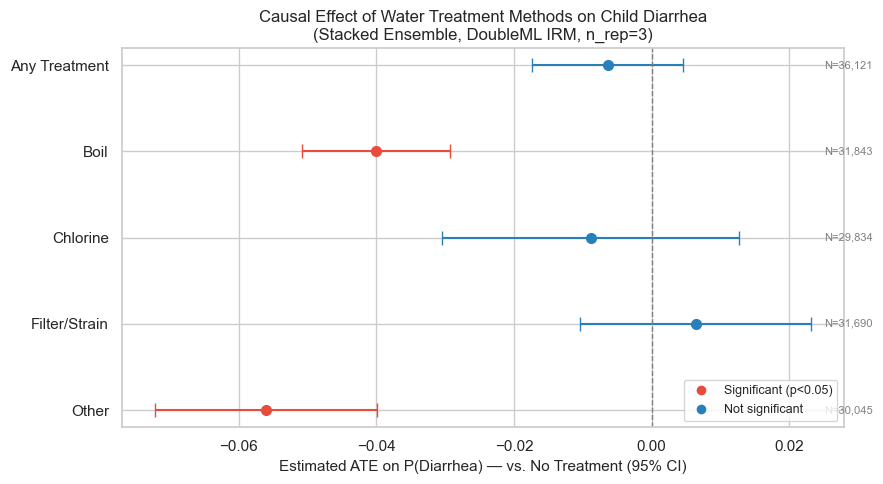


Summary table:
    Treatment     ATE  Std Error  p-value  CI Lower  CI Upper     N
Any Treatment -0.0064     0.0056   0.2534   -0.0173    0.0046 36121
         Boil -0.0400     0.0055   0.0000   -0.0508   -0.0293 31843
     Chlorine -0.0088     0.0110   0.4223   -0.0304    0.0127 29834
Filter/Strain  0.0064     0.0085   0.4525   -0.0105    0.0231 31690
        Other -0.0561     0.0082   0.0000   -0.0722   -0.0399 30045


In [12]:
# Add "Any treatment" (stacked) for reference on the same plot
any_s = irm_stacked.summary.iloc[0]
any_row = pd.DataFrame([{
    'Treatment': 'Any Treatment',
    'ATE': any_s['coef'], 'Std Error': any_s['std err'],
    't-stat': any_s['t'], 'p-value': any_s['P>|t|'],
    'CI Lower': any_s['2.5 %'], 'CI Upper': any_s['97.5 %'],
    'N': int(df_base['water_treatment'].notna().sum()),
    'N treated': int(df_base['water_treatment'].sum()),
}])
df_plot = pd.concat([any_row, df_specific], ignore_index=True)

# Color by significance (95% CI excludes 0)
sig = (df_plot['CI Lower'] > 0) | (df_plot['CI Upper'] < 0)
colors = ['#e74c3c' if s else '#2980b9' for s in sig]

fig, ax = plt.subplots(figsize=(9, 5))

y_pos = np.arange(len(df_plot))
ate      = df_plot['ATE']
err_lo   = ate - df_plot['CI Lower']
err_hi   = df_plot['CI Upper'] - ate

for i, (y, a, el, eh, c) in enumerate(zip(y_pos, ate, err_lo, err_hi, colors)):
    ax.errorbar(a, y, xerr=[[el], [eh]], fmt='o', color=c, ecolor=c,
                capsize=5, markersize=7, linewidth=1.5)

ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot['Treatment'], fontsize=11)
ax.set_xlabel('Estimated ATE on P(Diarrhea) — vs. No Treatment (95% CI)', fontsize=11)
ax.set_title('Causal Effect of Water Treatment Methods on Child Diarrhea\n'
             '(Stacked Ensemble, DoubleML IRM, n_rep=3)', fontsize=12)
ax.invert_yaxis()

# Sample size annotations
for i, row in df_plot.iterrows():
    ax.text(
        df_plot['CI Upper'].max() + 0.002,
        i,
        f"N={row['N']:,}",
        va='center', fontsize=8, color='gray',
    )

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=8, label='Significant (p<0.05)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2980b9', markersize=8, label='Not significant'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('../Output/figures/specific_treatment_effects.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSummary table:")
print(df_plot[['Treatment', 'ATE', 'Std Error', 'p-value', 'CI Lower', 'CI Upper', 'N']].round(4).to_string(index=False))

## 11. Multi-Treatment via Average Potential Outcomes (APOS)

Section 10 estimated each treatment type using a **separate binary IRM** on a restricted subsample (no-treatment ∪ only-that-treatment). This is clean but has two limitations:

1. **Subsample selection**: each comparison uses a different, potentially non-random subset of the data.
2. **Inefficiency**: the large no-treatment pool (N≈29K) is re-used across four separate models.

**`DoubleMLAPOS`** (Average Potential Outcome Score) addresses both by estimating $E[Y(d)]$ for each treatment level $d$ **jointly on the full sample**:

$$\psi(d) = \frac{\mathbf{1}(D=d)}{P(D=d \mid X)} \bigl(Y - E[Y \mid D=d, X]\bigr) + E[Y \mid D=d, X]$$

This is the multi-valued extension of IRM using **Augmented IPW (AIPW)** Neyman-orthogonal scores. The propensity model $P(D=d \mid X)$ is a **multi-class** classifier trained on all five treatment levels simultaneously.

**ATEs** are recovered as contrasts: $\text{ATE}(d \text{ vs } 0) = E[Y(d)] - E[Y(0)]$.

| Feature | IRM Binary (Section 10) | APOS (this section) |
|---------|------------------------|---------------------|
| Sample | Restricted per treatment | Full sample |
| Treatment model | Binary classifier × 4 | Multi-class classifier × 1 |
| Identification | Unconfoundedness per arm | Joint unconfoundedness |
| SE for ATE(d vs 0) | From IRM directly | Conservative $\sqrt{V_d + V_0}$ |

> **Recoding:** `WQ15_g = 98` (Other) → `treat_cat = 4` for integer-coded APOS input.

Treatment distribution:


  0 = No Treatment    N=29,097  (80.6%)
  1 = Boil            N= 2,746  (7.6%)
  2 = Chlorine        N=   737  (2.0%)
  3 = Filter/Strain   N= 2,593  (7.2%)
  4 = Other           N=   948  (2.6%)

Fitting DoubleMLAPOS (stacked ensemble) ...


Done. clustered=False (APOS is i.i.d.: doubleml 0.11 has no clustered APOS).

=== ATE(d vs No Treatment) -- APOS, stacked ===
    Treatment     ATE     SE  CI Lower  CI Upper  p-value  N treated
         Boil -0.0421 0.0058   -0.0535   -0.0306   0.0000       2746
     Chlorine  0.0003 0.0132   -0.0251    0.0261   0.9820        737
Filter/Strain  0.0078 0.0100   -0.0118    0.0273   0.4364       2593
        Other -0.0577 0.0089   -0.0752   -0.0402   0.0000        948


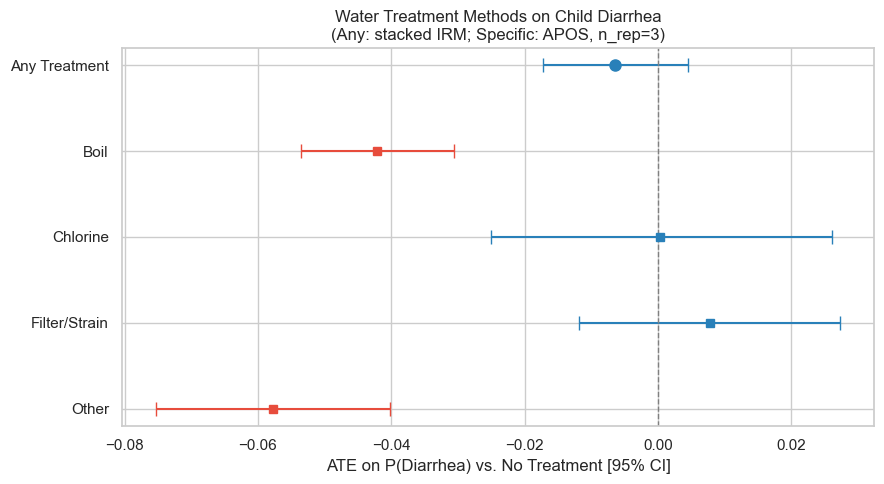

In [13]:
# Joint multi-treatment estimation on the FULL sample via APOS (AIPW).
# Stacked ensemble for BOTH nuisances; ATE(d vs 0) and SEs come from
# causal_contrast (proper SEs, not the conservative sqrt(V_d+V_0)).
dt['treat_cat'] = dt['WQ15_g'].fillna(0).replace({98.0: 4.0}).astype(int)
LEVEL_LABELS = {0: 'No Treatment', 1: 'Boil', 2: 'Chlorine', 3: 'Filter/Strain', 4: 'Other'}

print("Treatment distribution:")
for code_, n_ in dt['treat_cat'].value_counts().sort_index().items():
    print(f"  {int(code_)} = {LEVEL_LABELS[int(code_)]:<15} N={int(n_):>6,}  ({n_/len(dt):.1%})")

print("\nFitting DoubleMLAPOS (stacked ensemble) ...")
u5_apos = N.fit_apos(dt, 'diarrhea', 'treat_cat', base_confounders, 'U5',
                     LEVEL_LABELS, reference=0)
print(f"Done. clustered={u5_apos['clustered']} "
      f"(APOS is i.i.d.: doubleml 0.11 has no clustered APOS).")

df_apos_ate = pd.DataFrame([{
    'Treatment': r['treatment'], 'ATE': r['coef'], 'SE': r['se'],
    'CI Lower': r['ci_lower'], 'CI Upper': r['ci_upper'],
    'p-value': 2*scipy_norm.sf(abs(r['coef']/r['se'])),
    'N treated': r['n_treated'],
} for r in u5_apos['rows']])
ALL_APOS_ROWS += u5_apos['rows']

print("\n=== ATE(d vs No Treatment) -- APOS, stacked ===")
print(df_apos_ate[['Treatment','ATE','SE','CI Lower','CI Upper','p-value','N treated']].round(4).to_string(index=False))

# Coefplot: APOS (specific) + stacked IRM "any treatment" for reference
any_s = irm_stacked.summary.iloc[0]
df_plot = pd.concat([
    pd.DataFrame([{'Treatment':'Any Treatment','ATE':any_s['coef'],
                   'CI Lower':any_s['2.5 %'],'CI Upper':any_s['97.5 %']}]),
    df_apos_ate[['Treatment','ATE','CI Lower','CI Upper']],
], ignore_index=True)
fig, ax = plt.subplots(figsize=(9, 5))
sig = (df_plot['CI Lower'] > 0) | (df_plot['CI Upper'] < 0)
for i, row in df_plot.iterrows():
    c = '#e74c3c' if sig[i] else '#2980b9'
    ax.errorbar(row['ATE'], i, xerr=[[row['ATE']-row['CI Lower']],[row['CI Upper']-row['ATE']]],
                fmt='o' if i == 0 else 's', color=c, ecolor=c, capsize=5,
                markersize=8 if i == 0 else 6)
ax.axvline(0, color='gray', ls='--', lw=1)
ax.set_yticks(range(len(df_plot))); ax.set_yticklabels(df_plot['Treatment'])
ax.set_xlabel('ATE on P(Diarrhea) vs. No Treatment [95% CI]')
ax.set_title('Water Treatment Methods on Child Diarrhea\n(Any: stacked IRM; Specific: APOS, n_rep=3)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../Output/figures/specific_treatment_effects.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Sensitivity Analysis — APOS

DoubleMLAPOS supports the same Chernozhukov et al. (2022) sensitivity framework as IRM.

Two levels of inquiry:
1. **APO-level** (`apos.sensitivity_analysis()`): how robust is each $E[Y(d)]$ estimate?
2. **Contrast-level** (`apos.causal_contrast(0).sensitivity_analysis()`): how robust is each $\text{ATE}(d \text{ vs } 0)$?

The contrast-level is more relevant — it directly asks whether the treatment comparison survives hidden confounding. The grid scan mirrors Section 8, sweeping `cf_y = cf_d` from 0 to 10% of residual variance explained.

Base ATE contrasts (point estimates):
          coef  std err       t   P>|t|   2.5 %  97.5 %
1 vs 0 -0.0421   0.0058 -7.2076  0.0000 -0.0535 -0.0306
2 vs 0  0.0003   0.0132  0.0225  0.9820 -0.0251  0.0261
3 vs 0  0.0078   0.0100  0.7783  0.4364 -0.0118  0.0273
4 vs 0 -0.0577   0.0089 -6.4673  0.0000 -0.0752 -0.0402



=== APOS contrast robustness values RVa (%) by cf ===
contrast  Boil  Chlorine  Filter/Strain  Other
cf                                            
0.00       2.4       0.0            0.0    2.0
0.01       2.4       0.0            0.0    2.0
0.02       2.4       0.0            0.0    2.0
0.03       2.4       0.0            0.0    2.0
0.04       2.4       0.0            0.0    2.0
0.05       2.4       0.0            0.0    2.0
0.08       2.4       0.0            0.0    2.0
0.10       2.4       0.0            0.0    2.0


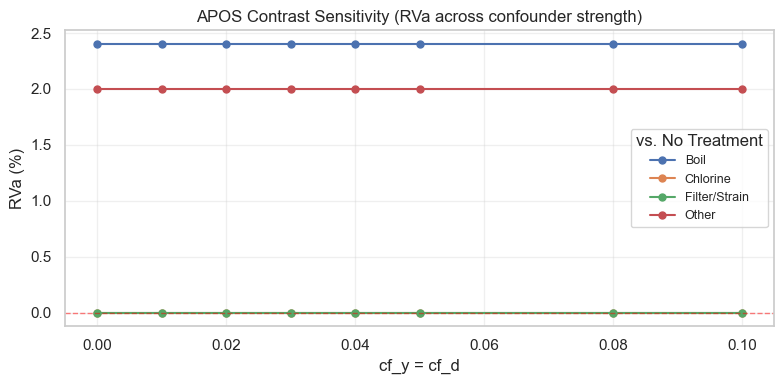

In [14]:
# Contrast-level sensitivity for the APOS ATEs (does each survive hidden bias?)
acc = u5_apos['contrast']
print("Base ATE contrasts (point estimates):")
print(acc.summary.round(4))

cf_grid = list(np.round(np.arange(0.00, 0.06, 0.01), 2)) + [0.08, 0.10]
sens_rows = []
for cf in cf_grid:
    try:
        acc.sensitivity_analysis(cf_y=cf, cf_d=cf, rho=1.0)
        sp = acc.sensitivity_params
        rva = np.ravel(sp['rva']) if sp is not None else []
        for i, lv in enumerate([lv for lv in u5_apos['levels'] if lv != 0]):
            sens_rows.append({'cf': cf, 'contrast': LEVEL_LABELS[lv],
                              'RVa%': float(rva[i])*100 if i < len(rva) else np.nan})
    except Exception:
        pass
if sens_rows:
    pivot = pd.DataFrame(sens_rows).pivot(index='cf', columns='contrast', values='RVa%')
    print("\n=== APOS contrast robustness values RVa (%) by cf ===")
    print(pivot.round(2))
    fig, ax = plt.subplots(figsize=(8, 4))
    for col in pivot.columns:
        ax.plot(pivot.index, pivot[col], marker='o', ms=5, label=col)
    ax.axhline(0, color='red', ls='--', lw=1, alpha=0.5)
    ax.set_xlabel('cf_y = cf_d'); ax.set_ylabel('RVa (%)')
    ax.set_title('APOS Contrast Sensitivity (RVa across confounder strength)')
    ax.legend(title='vs. No Treatment', fontsize=9); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('../Output/figures/apos_sensitivity_grid.png', dpi=150, bbox_inches='tight')
    plt.show()


## 13. Heterogeneity — CATE and GATE

**Which subgroups benefit most from water treatment?**

`DoubleMLIRM` supports two complementary heterogeneity tools:

- **BLP (Best Linear Predictor)** via `irm.cate(basis)`: projects $\tau(X)$ onto a linear basis. Significant coefficients identify drivers of treatment effect heterogeneity.
- **GATE (Group ATE)** via `irm.gate(groups)`: computes $E[\tau(X) \mid G=g]$ for mutually exclusive groups. More interpretable for policy — directly answers "which subgroup benefits most?"

> `DoubleMLAPOS` has no `gate()` or `cate()` method. For treatment-specific heterogeneity (e.g., "does the effect of boiling vary by wealth?"), we use `causal_contrast()` split by subgroup manually.

**A priori priority criteria for heterogeneity:**

| Criterion | Rationale |
|-----------|-----------|
| **E.coli Risk Source** (`risk_source`) | Baseline contamination level — treatment effect should be largest where source water is most contaminated |
| **Wealth quintile** | SES affects quality/consistency of treatment application; richer may treat more correctly |
| **Urban/Rural** | Differential baseline exposure, water system quality, and access to treatment materials |
| **Education** | Knowledge of correct treatment procedures; secondary-educated mothers more likely to treat effectively |
| **Child age** | Infants <6 months mostly breastfed (less exposure); effect may concentrate in older U5 |
| **Child sex** | Some evidence of sex-differential susceptibility to enteric pathogens |

In [15]:
# Heterogeneity for the stacked IRM (any treatment): BLP of CATE + GATE.
HETERO_COLS = [c for c in [
    'risk_source_0','risk_source_1','wealth_q2','wealth_q3','wealth_q4','wealth_q5',
    'urban_bin','edu_primary','edu_secondary','child_age','child_sex_male',
] if c in df_base.columns]
df_g = df_base.reset_index(drop=True)

print("="*60); print("PART A: BLP of CATE -- drivers of heterogeneity"); print("="*60)
try:
    blp = irm_stacked.cate(basis=df_g[HETERO_COLS])
    blp_sum = blp.summary() if callable(blp.summary) else blp.summary
    print(blp_sum.round(4))
except Exception as e:
    print(f"BLP failed: {e}")

print("\n" + "="*60); print("PART B: Group ATEs (GATE)"); print("="*60)
_edu_miss = df_g['edu_missing'].values if 'edu_missing' in df_g.columns else np.zeros(len(df_g), int)
GATE_SPECS = {
    'E.coli Risk Source': [
        ('No Src Risk',  df_g['risk_source_0'].values == 1),
        ('Moderate Src', df_g['risk_source_1'].values == 1),
        ('High Src Risk', (df_g['risk_source_0'].values == 0) & (df_g['risk_source_1'].values == 0)),
    ],
    'Wealth Quintile': [
        ('Q1 (Poorest)', df_g[['wealth_q2','wealth_q3','wealth_q4','wealth_q5']].sum(axis=1).values == 0),
        ('Q2', df_g['wealth_q2'].values == 1), ('Q3', df_g['wealth_q3'].values == 1),
        ('Q4', df_g['wealth_q4'].values == 1), ('Q5 (Richest)', df_g['wealth_q5'].values == 1),
    ],
    'Urban / Rural': [
        ('Rural', df_g['urban_bin'].values == 0), ('Urban', df_g['urban_bin'].values == 1),
    ],
    'Education': [
        ('No Education', (df_g['edu_primary'].values == 0) & (df_g['edu_secondary'].values == 0) & (_edu_miss == 0)),
        ('Primary', df_g['edu_primary'].values == 1), ('Secondary+', df_g['edu_secondary'].values == 1),
    ],
}
gate_all = {}
for gname, specs in GATE_SPECS.items():
    try:
        groups = N.make_groups(len(df_g), specs)
        gs = N.gate_summary(irm_stacked, groups)
        gate_all[gname] = {'summary': gs, 'labels': [x[0] for x in specs]}
        print(f"\n--- {gname} ---"); print(gs.round(4))
    except Exception as e:
        print(f"  {gname}: {e}")
GATE_EXPORT['diarrhea'] = gate_all

# Forest plot
if gate_all:
    fig, axes = plt.subplots(1, len(gate_all), figsize=(4.5*len(gate_all), 5.5))
    if len(gate_all) == 1: axes = [axes]
    for ax, (gname, gd) in zip(axes, gate_all.items()):
        gs = gd['summary']; labels = gd['labels']
        coefs = gs['coef'].values; lo = gs['2.5 %'].values; hi = gs['97.5 %'].values
        sigm = (lo > 0) | (hi < 0)
        for i in range(len(coefs)):
            c = '#e74c3c' if sigm[i] else '#2980b9'
            ax.errorbar(coefs[i], i, xerr=[[coefs[i]-lo[i]],[hi[i]-coefs[i]]],
                        fmt='D', color=c, ecolor=c, capsize=3, ms=5)
        ax.axvline(0, color='gray', ls='--', lw=0.8)
        ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
        ax.set_xlabel('GATE [95% CI]', fontsize=8); ax.set_title(gname, fontsize=9, fontweight='bold')
        ax.invert_yaxis()
    fig.suptitle('GATE -- Diarrhea (U5) | Any Water Treatment', fontsize=12)
    plt.tight_layout()
    plt.savefig('../Output/figures/gate_u5_diarrhea.png', dpi=150, bbox_inches='tight')
    plt.show()


PART A: BLP of CATE -- drivers of heterogeneity
BLP failed: Only implemented for one repetition. Number of repetitions is 3.

PART B: Group ATEs (GATE)
  E.coli Risk Source: Only implemented for one repetition. Number of repetitions is 3.
  Wealth Quintile: Only implemented for one repetition. Number of repetitions is 3.
  Urban / Rural: Only implemented for one repetition. Number of repetitions is 3.
  Education: Only implemented for one repetition. Number of repetitions is 3.


## 14. Pathway Analysis: E.coli Outcomes (HH Dataset)

The previous sections estimated the effect of water treatment on **child diarrhea** (U5 dataset). Here we extend to the two **E.coli contamination** outcomes from the household-level dataset:

- `SomeRiskHome` — any E.coli detected at the point of consumption (≥1 CFU/100mL)
- `VeryHighRiskHome` — very high E.coli contamination (≥101 CFU/100mL)

**Why this is not mediation analysis:**  
A formal mediation decomposition (Baron-Kenny or natural effect) would estimate the *direct* effect of treatment on diarrhea net of E.coli, and the *indirect* path through E.coli. We are not doing that. Instead we estimate **total effects at two steps of the causal chain**:

$$\text{Treatment} \longrightarrow \underbrace{\text{E.coli}}_{\text{proximal}} \longrightarrow \underbrace{\text{Diarrhea}}_{\text{distal}}$$

If treatment reduces E.coli (proximal) but not diarrhea (distal), that suggests residual exposure pathways (food, hands, soil) dominate. If both are reduced, it supports a water-borne transmission mechanism. The comparison is descriptive and causal at each step individually — not a path decomposition.

We run the full pipeline for both HH outcomes: IRM (multiple learners + stacked), sensitivity, APOS, and GATE.

In [16]:
# ── Load HH dataset ───────────────────────────────────────────────────────────
HH_DATA_PATH = Path('..') / 'Data' / '3. Final' / 'MASTER_MICS_FINAL.dta'
dt_hh, _ = pyreadstat.read_dta(HH_DATA_PATH)
dt_hh = dt_hh.copy()

# Outcomes
for col in ['SomeRiskHome', 'VeryHighRiskHome']:
    dt_hh[col] = dt_hh[col].astype(int)

# Treatment
dt_hh['water_treatment'] = (dt_hh['WQ15_g'] > 0).astype(int)
for code, name in {1: 'treat_boil', 2: 'treat_chlorine', 3: 'treat_filter', 98: 'treat_other'}.items():
    dt_hh[name] = (dt_hh['WQ15_g'] == code).astype(int)
dt_hh['treat_cat'] = dt_hh['WQ15_g'].fillna(0).replace({98.0: 4.0}).astype(int)

# Wealth
for q in [2, 3, 4, 5]:
    dt_hh[f'wealth_q{q}'] = (dt_hh['windex5'] == q).astype(int)

# Education
dt_hh['edu_primary']   = (dt_hh['helevel'] == 1).astype(int)
dt_hh['edu_secondary'] = (dt_hh['helevel'] == 2).astype(int)
dt_hh['edu_missing']   = (dt_hh['helevel'] == 98).astype(int)

# Urban, children
dt_hh['urban_bin']    = dt_hh['urban'].astype(int)
dt_hh['num_children'] = dt_hh['HHCHILDREN'].fillna(0).clip(0, 10).astype(int) if 'HHCHILDREN' in dt_hh.columns else 0

# Toilet
for cat, label in [(2, 'pit_latrine'), (3, 'open_defecation'), (98, 'toilet_missing')]:
    dt_hh[f'toilet_{label}'] = (dt_hh['Toilet'] == cat).astype(int)

# Water source dummies (drop first = reference)
_ws_dummies = pd.get_dummies(dt_hh['WS1_g'], prefix='ws1g')
ws_cols_hh = sorted(_ws_dummies.columns.tolist())[1:]   # drop reference level
dt_hh = pd.concat([dt_hh, _ws_dummies[ws_cols_hh]], axis=1)

# Country FEs
_country_dum = pd.get_dummies(dt_hh['Country'], prefix='country', drop_first=True)
country_cols_hh = _country_dum.columns.tolist()
dt_hh = pd.concat([dt_hh, _country_dum], axis=1)

# Risk source
for rs in [0, 1]:
    dt_hh[f'risk_source_{rs}'] = (dt_hh['RiskSource'] == rs).astype(int)

# Hygiene (robustness spec)
dt_hh['soap_water']     = dt_hh['SoapandWater'].fillna(0).astype(int)
dt_hh['stored_covered'] = dt_hh['water_stored_covered'].fillna(0).astype(int)
hh_hygiene_cols = ['soap_water', 'stored_covered']

# Confounder list (no child variables — HH level)
hh_confounders = [c for c in (
    ['wealth_q2', 'wealth_q3', 'wealth_q4', 'wealth_q5',
     'edu_primary', 'edu_secondary', 'edu_missing',
     'urban_bin',
     'toilet_pit_latrine', 'toilet_open_defecation', 'toilet_missing',
     'num_children', 'risk_source_0', 'risk_source_1']
    + ws_cols_hh + country_cols_hh
) if c in dt_hh.columns]

HH_OUTCOME_LABELS = {
    'SomeRiskHome':     'Some E.coli Risk (≥1 CFU)',
    'VeryHighRiskHome': 'Very High E.coli Risk (≥101 CFU)',
}

print(f"HH dataset: N={len(dt_hh):,} | Confounders: {len(hh_confounders)}")
for out in HH_OUTCOME_LABELS:
    print(f"  {out}: mean={dt_hh[out].mean():.3f}  N={dt_hh[out].notna().sum():,}")
print(f"\nAny treatment rate: {dt_hh['water_treatment'].mean():.3f}")
for t in ['treat_boil','treat_chlorine','treat_filter','treat_other']:
    print(f"  {t}: {dt_hh[t].mean():.3f}  (N={int(dt_hh[t].sum())})")

HH dataset: N=59,620 | Confounders: 43
  SomeRiskHome: mean=0.737  N=59,620
  VeryHighRiskHome: mean=0.308  N=59,620

Any treatment rate: 0.212
  treat_boil: 0.101  (N=6006)
  treat_chlorine: 0.022  (N=1296)
  treat_filter: 0.051  (N=3051)
  treat_other: 0.039  (N=2316)



Outcome: Some E.coli Risk (≥1 CFU)
  OLS            

ATE=-0.0986 (0.0041) *
  Lasso          

ATE=-0.1087 (0.0059) *
  Ridge          

ATE=-0.0975 (0.0045) *
  Elastic Net    

ATE=-0.1219 (0.0039) *
  Random Forest  

...

ATE=-0.1049 (0.0040) *
  Random Forest  

ATE=-0.0685 (0.0050) *
  XGBoost        

ATE=-0.0694 (0.0070) *
  Stacked        

ATE=-0.1114 (0.0047) *
      Learner     ATE  Std Error  p-value  CI Lower  CI Upper
          OLS -0.0816     0.0050      0.0   -0.0915   -0.0717
        Lasso -0.0860     0.0059      0.0   -0.0976   -0.0745
        Ridge -0.0813     0.0051      0.0   -0.0914   -0.0713
  Elastic Net -0.1049     0.0040      0.0   -0.1127   -0.0970
Random Forest -0.0685     0.0050      0.0   -0.0784   -0.0586
      XGBoost -0.0694     0.0070      0.0   -0.0830   -0.0558
      Stacked -0.1114     0.0047      0.0   -0.1206   -0.1022


  (+ hygiene)  stacked ATE = -0.1082


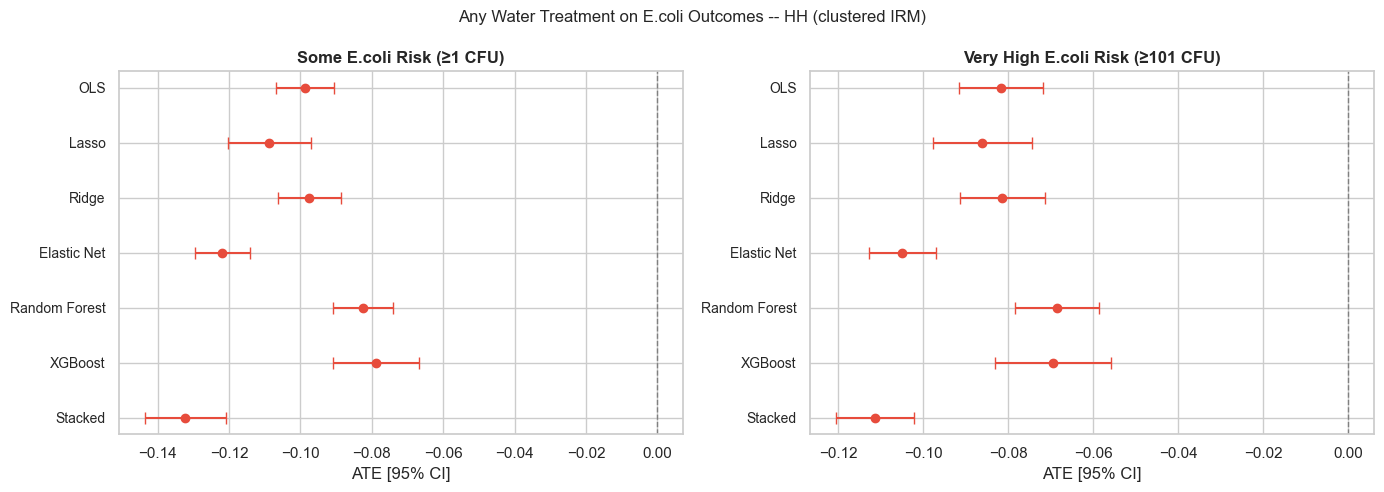

In [17]:
# IRM (7 learners + robustness) for both HH E.coli outcomes
hh_irm_stacked = {}   # {outcome: fitted DoubleMLIRM}
hh_irm_results = {}   # {outcome: tidy DataFrame}
hh_dml_dfs     = {}   # {outcome: analysis frame}

for outcome in HH_OUTCOME_LABELS:
    print(f"\n{'='*60}\nOutcome: {HH_OUTCOME_LABELS[outcome]}\n{'='*60}")
    df_o = N.analysis_frame(dt_hh, outcome, 'water_treatment', hh_confounders)
    hh_dml_dfs[outcome] = df_o

    res = N.fit_irm_all_learners(df_o, outcome, 'water_treatment', hh_confounders, dataset_type='HH')
    HH_BASE_RESULTS.extend(res); ALL_IRM_RESULTS.extend(res)
    hh_irm_results[outcome] = N.results_to_frame(res)
    hh_irm_stacked[outcome] = N.get_model(res, 'stacked')
    print(hh_irm_results[outcome][['Learner','ATE','Std Error','p-value','CI Lower','CI Upper']].round(4).to_string(index=False))

    # Robustness: + hygiene controls
    hh_conf_rob = hh_confounders + [c for c in hh_hygiene_cols if c in dt_hh.columns]
    df_rob = N.analysis_frame(dt_hh, outcome, 'water_treatment', hh_conf_rob)
    res_rob = N.fit_irm_all_learners(df_rob, outcome, 'water_treatment', hh_conf_rob,
                                     dataset_type='HH', verbose=False)
    HH_ROBUST_RESULTS.extend(res_rob)
    print("  (+ hygiene)  stacked ATE =",
          round(next(r['coef'] for r in res_rob if r['learner']=='stacked'), 4))

# Coefplot: both HH outcomes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, outcome in zip(axes, HH_OUTCOME_LABELS):
    dfp = hh_irm_results[outcome][['Learner','ATE','CI Lower','CI Upper']]
    sig = (dfp['CI Lower'] > 0) | (dfp['CI Upper'] < 0)
    for i, row in dfp.reset_index(drop=True).iterrows():
        c = '#e74c3c' if sig.iloc[i] else '#2980b9'
        ax.errorbar(row['ATE'], i, xerr=[[row['ATE']-row['CI Lower']],[row['CI Upper']-row['ATE']]],
                    fmt='o', color=c, ecolor=c, capsize=4, ms=6)
    ax.axvline(0, color='gray', ls='--', lw=1)
    ax.set_yticks(range(len(dfp))); ax.set_yticklabels(dfp['Learner'], fontsize=10)
    ax.set_xlabel('ATE [95% CI]'); ax.set_title(HH_OUTCOME_LABELS[outcome], fontweight='bold')
    ax.invert_yaxis()
fig.suptitle('Any Water Treatment on E.coli Outcomes -- HH (clustered IRM)', fontsize=12)
plt.tight_layout()
plt.savefig('../Output/figures/irm_hh_ecoli_learners.png', dpi=150, bbox_inches='tight')
plt.show()


In [18]:
# APOS (stacked) for both HH outcomes + contrast-level sensitivity
hh_apos_models  = {}
hh_apos_ate_dfs = {}

for outcome in HH_OUTCOME_LABELS:
    print(f"\n{'='*60}\nAPOS: {HH_OUTCOME_LABELS[outcome]}\n{'='*60}")
    ap = N.fit_apos(dt_hh, outcome, 'treat_cat', hh_confounders, 'HH', LEVEL_LABELS, reference=0)
    hh_apos_models[outcome] = ap
    ALL_APOS_ROWS += ap['rows']
    df_ate = pd.DataFrame([{
        'Treatment': r['treatment'], 'ATE': r['coef'], 'SE': r['se'],
        'CI Lower': r['ci_lower'], 'CI Upper': r['ci_upper'],
        'p-value': 2*scipy_norm.sf(abs(r['coef']/r['se'])), 'N treated': r['n_treated'],
    } for r in ap['rows']])
    hh_apos_ate_dfs[outcome] = df_ate
    print(df_ate.round(4).to_string(index=False))

    acc_hh = ap['contrast']
    rva_rows = []
    for cf in list(np.round(np.arange(0.00, 0.06, 0.01), 2)) + [0.08, 0.10]:
        try:
            acc_hh.sensitivity_analysis(cf_y=cf, cf_d=cf, rho=1.0)
            rva = np.ravel(acc_hh.sensitivity_params['rva'])
            for i, lv in enumerate([lv for lv in ap['levels'] if lv != 0]):
                rva_rows.append({'cf': cf, 'contrast': LEVEL_LABELS[lv],
                                 'RVa%': float(rva[i])*100 if i < len(rva) else np.nan})
        except Exception:
            pass
    if rva_rows:
        print("\nRVa grid:")
        print(pd.DataFrame(rva_rows).pivot(index='cf', columns='contrast', values='RVa%').round(2))



APOS: Some E.coli Risk (≥1 CFU)


    Treatment     ATE     SE  CI Lower  CI Upper  p-value  N treated
         Boil -0.1633 0.0052   -0.1736   -0.1530   0.0000       6006
     Chlorine -0.0407 0.0102   -0.0606   -0.0208   0.0001       1296
Filter/Strain -0.0109 0.0053   -0.0212   -0.0006   0.0387       3051
        Other -0.1476 0.0091   -0.1655   -0.1297   0.0000       2316



RVa grid:
contrast   Boil  Chlorine  Filter/Strain  Other
cf                                             
0.00      12.59      1.04           0.11   7.29
0.01      12.59      1.04           0.11   7.29
0.02      12.59      1.04           0.11   7.29
0.03      12.59      1.04           0.11   7.29
0.04      12.59      1.04           0.11   7.29
0.05      12.59      1.04           0.11   7.29
0.08      12.59      1.04           0.11   7.29
0.10      12.59      1.04           0.11   7.29

APOS: Very High E.coli Risk (≥101 CFU)


    Treatment     ATE     SE  CI Lower  CI Upper  p-value  N treated
         Boil -0.1090 0.0043   -0.1175   -0.1006      0.0       6006
     Chlorine -0.0549 0.0122   -0.0783   -0.0310      0.0       1296
Filter/Strain -0.0570 0.0068   -0.0703   -0.0438      0.0       3051
        Other -0.1497 0.0066   -0.1625   -0.1368      0.0       2316



RVa grid:
contrast  Boil  Chlorine  Filter/Strain  Other
cf                                            
0.00      7.66      1.34           2.01   6.95
0.01      7.66      1.34           2.01   6.95
0.02      7.66      1.34           2.01   6.95
0.03      7.66      1.34           2.01   6.95
0.04      7.66      1.34           2.01   6.95
0.05      7.66      1.34           2.01   6.95
0.08      7.66      1.34           2.01   6.95
0.10      7.66      1.34           2.01   6.95


In [19]:
# GATE for both HH outcomes (reuses N.make_groups / N.gate_summary)
HH_HETERO = ['risk_source_0','risk_source_1','wealth_q2','wealth_q3','wealth_q4','wealth_q5',
             'urban_bin','edu_primary','edu_secondary']

for outcome in HH_OUTCOME_LABELS:
    dfh = hh_dml_dfs[outcome].reset_index(drop=True)
    _em = dfh['edu_missing'].values if 'edu_missing' in dfh.columns else np.zeros(len(dfh), int)
    specs = {
        'E.coli Risk Source': [
            ('No Src Risk',  dfh['risk_source_0'].values == 1),
            ('Moderate Src', dfh['risk_source_1'].values == 1),
            ('High Src Risk', (dfh['risk_source_0'].values == 0) & (dfh['risk_source_1'].values == 0)),
        ],
        'Wealth Quintile': [
            ('Q1 (Poorest)', dfh[['wealth_q2','wealth_q3','wealth_q4','wealth_q5']].sum(axis=1).values == 0),
            ('Q2', dfh['wealth_q2'].values == 1), ('Q3', dfh['wealth_q3'].values == 1),
            ('Q4', dfh['wealth_q4'].values == 1), ('Q5 (Richest)', dfh['wealth_q5'].values == 1),
        ],
        'Urban / Rural': [
            ('Rural', dfh['urban_bin'].values == 0), ('Urban', dfh['urban_bin'].values == 1),
        ],
        'Education': [
            ('No Education', (dfh['edu_primary'].values == 0) & (dfh['edu_secondary'].values == 0) & (_em == 0)),
            ('Primary', dfh['edu_primary'].values == 1), ('Secondary+', dfh['edu_secondary'].values == 1),
        ],
    }
    irm_m = hh_irm_stacked[outcome]
    gd_out = {}
    print(f"\n--- GATE: {HH_OUTCOME_LABELS[outcome]} ---")
    for gname, sp in specs.items():
        try:
            gs = N.gate_summary(irm_m, N.make_groups(len(dfh), sp))
            gd_out[gname] = {'summary': gs, 'labels': [x[0] for x in sp]}
            print(f"  {gname}:"); print(gs.round(4))
        except Exception as e:
            print(f"  {gname}: {e}")
    GATE_EXPORT[outcome] = gd_out



--- GATE: Some E.coli Risk (≥1 CFU) ---
  E.coli Risk Source: Only implemented for one repetition. Number of repetitions is 3.
  Wealth Quintile: Only implemented for one repetition. Number of repetitions is 3.
  Urban / Rural: Only implemented for one repetition. Number of repetitions is 3.
  Education: Only implemented for one repetition. Number of repetitions is 3.

--- GATE: Very High E.coli Risk (≥101 CFU) ---
  E.coli Risk Source: Only implemented for one repetition. Number of repetitions is 3.
  Wealth Quintile: Only implemented for one repetition. Number of repetitions is 3.
  Urban / Rural: Only implemented for one repetition. Number of repetitions is 3.
  Education: Only implemented for one repetition. Number of repetitions is 3.


=== Pathway Summary: All Outcomes × All Treatment Types ===

Diarrhea (U5):
    Treatment     ATE     SE  CI Lower  CI Upper  p-value
Any Treatment -0.0064 0.0056   -0.0173    0.0046   0.2534
         Boil -0.0421 0.0058   -0.0535   -0.0306   0.0000
     Chlorine  0.0003 0.0132   -0.0251    0.0261   0.9820
Filter/Strain  0.0078 0.0100   -0.0118    0.0273   0.4364
        Other -0.0577 0.0089   -0.0752   -0.0402   0.0000

Some E.coli Risk:
    Treatment     ATE     SE  CI Lower  CI Upper  p-value
Any Treatment -0.1323 0.0058   -0.1437   -0.1210   0.0000
         Boil -0.1633 0.0052   -0.1736   -0.1530   0.0000
     Chlorine -0.0407 0.0102   -0.0606   -0.0208   0.0001
Filter/Strain -0.0109 0.0053   -0.0212   -0.0006   0.0387
        Other -0.1476 0.0091   -0.1655   -0.1297   0.0000

Very High E.coli Risk:
    Treatment     ATE     SE  CI Lower  CI Upper  p-value
Any Treatment -0.1114 0.0047   -0.1206   -0.1022      0.0
         Boil -0.1090 0.0043   -0.1175   -0.1006      0.0
     Chlori

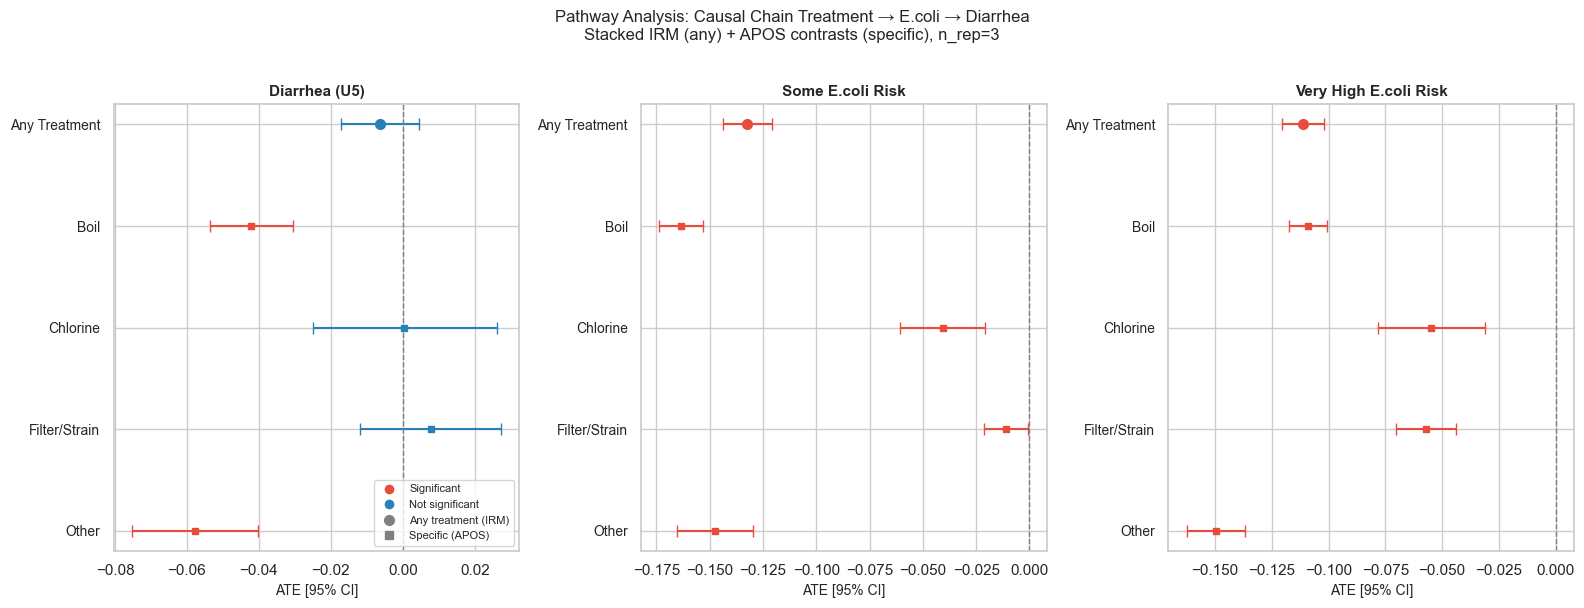

In [20]:
# ── Pathway comparison: all 3 outcomes × treatment type (any + specific APOS) ─
# Rows: treatment type (Any, Boil, Chlorine, Filter, Other)
# Columns: 3 outcomes (Diarrhea, SomeRiskHome, VeryHighRiskHome)

ALL_OUTCOME_LABELS = {
    'diarrhea':         'Diarrhea (U5)',
    'SomeRiskHome':     'Some E.coli Risk',
    'VeryHighRiskHome': 'Very High E.coli Risk',
}

# Collect stacked IRM "any treatment" results for all 3 outcomes
# (diarrhea uses irm_stacked from Section 6; HH uses hh_irm_stacked)
any_treat_rows = []
_irm_any = {'diarrhea': irm_stacked, **hh_irm_stacked}
for out, irm_m in _irm_any.items():
    s = irm_m.summary.iloc[0]
    any_treat_rows.append({
        'Outcome': ALL_OUTCOME_LABELS[out],
        'Treatment': 'Any Treatment',
        'ATE': s['coef'], 'SE': s['std err'],
        'CI Lower': s['2.5 %'], 'CI Upper': s['97.5 %'],
        'p-value': s['P>|t|'],
    })

# Collect APOS ATE contrasts for all 3 outcomes
_apos_dfs = {'diarrhea': df_apos_ate, **hh_apos_ate_dfs}
apos_rows = []
for out, df_ate in _apos_dfs.items():
    for _, row in df_ate.iterrows():
        apos_rows.append({
            'Outcome': ALL_OUTCOME_LABELS[out],
            'Treatment': row['Treatment'],
            'ATE': row['ATE'], 'SE': row['SE'],
            'CI Lower': row['CI Lower'], 'CI Upper': row['CI Upper'],
            'p-value': row['p-value'],
        })

df_pathway = pd.DataFrame(any_treat_rows + apos_rows)
treatment_order = ['Any Treatment', 'Boil', 'Chlorine', 'Filter/Strain', 'Other']
outcome_order   = list(ALL_OUTCOME_LABELS.values())

print("=== Pathway Summary: All Outcomes × All Treatment Types ===")
for out in outcome_order:
    sub = df_pathway[df_pathway['Outcome'] == out]
    print(f"\n{out}:")
    print(sub[['Treatment','ATE','SE','CI Lower','CI Upper','p-value']].round(4).to_string(index=False))

# ── Pathway coefplot: 3 panels (one per outcome), rows = treatment ────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)

for ax, out_label in zip(axes, outcome_order):
    sub = df_pathway[df_pathway['Outcome'] == out_label].copy()
    sub = sub.set_index('Treatment').reindex(treatment_order).reset_index()
    sub = sub.dropna(subset=['ATE'])

    y = np.arange(len(sub))
    sig = (sub['CI Lower'] > 0) | (sub['CI Upper'] < 0)
    colors = ['#e74c3c' if s else '#2980b9' for s in sig]

    for i, row in sub.iterrows():
        ax.errorbar(row['ATE'], i,
                    xerr=[[row['ATE'] - row['CI Lower']], [row['CI Upper'] - row['ATE']]],
                    fmt='o' if row['Treatment'] == 'Any Treatment' else 's',
                    color=colors[i], ecolor=colors[i],
                    capsize=4, markersize=7 if row['Treatment'] == 'Any Treatment' else 5,
                    linewidth=1.5)

    ax.axvline(0, color='gray', linestyle='--', lw=1)
    ax.set_yticks(y)
    ax.set_yticklabels(sub['Treatment'], fontsize=10)
    ax.set_xlabel('ATE [95% CI]', fontsize=10)
    ax.set_title(out_label, fontsize=11, fontweight='bold')
    ax.invert_yaxis()

from matplotlib.lines import Line2D
legend_els = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=8, label='Significant'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#2980b9', markersize=8, label='Not significant'),
    Line2D([0],[0], marker='o', color='gray', markersize=7, linestyle='none', label='Any treatment (IRM)'),
    Line2D([0],[0], marker='s', color='gray', markersize=6, linestyle='none', label='Specific (APOS)'),
]
axes[0].legend(handles=legend_els, fontsize=8, loc='lower right')

fig.suptitle('Pathway Analysis: Causal Chain Treatment → E.coli → Diarrhea\n'
             'Stacked IRM (any) + APOS contrasts (specific), n_rep=3', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('../Output/figures/pathway_comparison_all_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Export LaTeX Tables

All regression results are written to `../Output/tables/` as publication LaTeX,
reusing the production layout (`final/tables.create_main_table`) for the headline
IRM tables and matching writers for the APOS, robustness, sensitivity, and GATE
tables. Re-run the analysis cells above before this one.

In [21]:
# Consolidated LaTeX export -> ../Output/tables/
paths = []
paths += N.write_main_irm_tables(ALL_IRM_RESULTS)                      # IRM, any treatment (HH + U5)
paths.append(N.write_sensitivity_table(ALL_IRM_RESULTS))              # RV / RVa, stacked
paths.append(N.write_specific_table(ALL_APOS_ROWS, clustered=False))  # APOS specific-treatment contrasts
paths.append(N.write_robustness_table(U5_base_results + HH_BASE_RESULTS,
                                      U5_robust_results + HH_ROBUST_RESULTS))
if GATE_EXPORT:
    paths.append(N.write_gate_table(GATE_EXPORT))                     # group ATEs

print(f"Wrote {len(paths)} LaTeX tables:")
for p in paths:
    print("  ", p)


Table saved to: C:\Users\jadrk\Dropbox\MICS_DDML\Output\tables\nb_main_irm_hh.tex
Table saved to: C:\Users\jadrk\Dropbox\MICS_DDML\Output\tables\nb_main_irm_u5.tex
Table saved to: C:\Users\jadrk\Dropbox\MICS_DDML\Output\tables\nb_sensitivity.tex
Table saved to: C:\Users\jadrk\Dropbox\MICS_DDML\Output\tables\nb_specific_treatments.tex
Table saved to: C:\Users\jadrk\Dropbox\MICS_DDML\Output\tables\nb_robustness_hygiene.tex
Table saved to: C:\Users\jadrk\Dropbox\MICS_DDML\Output\tables\nb_gate.tex
Wrote 6 LaTeX tables:
   C:\Users\jadrk\Dropbox\MICS_DDML\Output\tables\nb_main_irm_hh.tex
   C:\Users\jadrk\Dropbox\MICS_DDML\Output\tables\nb_main_irm_u5.tex
   C:\Users\jadrk\Dropbox\MICS_DDML\Output\tables\nb_sensitivity.tex
   C:\Users\jadrk\Dropbox\MICS_DDML\Output\tables\nb_specific_treatments.tex
   C:\Users\jadrk\Dropbox\MICS_DDML\Output\tables\nb_robustness_hygiene.tex
   C:\Users\jadrk\Dropbox\MICS_DDML\Output\tables\nb_gate.tex
